# Exercise 1

In [6]:
import pandas as pd

df = pd.read_csv('./train.csv')

df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### Check for duplicates

In [9]:
duplicates = df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 0


### Remove duplicates

In [12]:
df = df.drop_duplicates()
print(f"Number of duplicates: {df.duplicated().sum()}")

Number of duplicates: 0


# Exercise 2

### Check columns with missing values

In [16]:
df.isna().sum()



,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Handling missing values

In [20]:
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

/tmp/ipython-input-617177261.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipython-input-617177261.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

# Exercise 3

### Feature engineering

In [22]:
# Creating FamilySize from sibSp and Parch
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Extract Title from Name
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

# Simplify rare titles
df["Title"] = df["Title"].replace(df["Title"].value_counts()[df["Title"].value_counts() < 10].index, "Rare")

df[["Name", "Title", "FamilySize"]].head()


<>:5: SyntaxWarning: invalid escape sequence '\.'
<>:5: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-2636948719.py:5: SyntaxWarning: invalid escape sequence '\.'
  df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)


,Name,Title,FamilySize
0,"Braund, Mr. Owen Harris",Mr,2
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2
2,"Heikkinen, Miss. Laina",Miss,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2
4,"Allen, Mr. William Henry",Mr,1


# Exercise 4: Outlier Detection and Handling

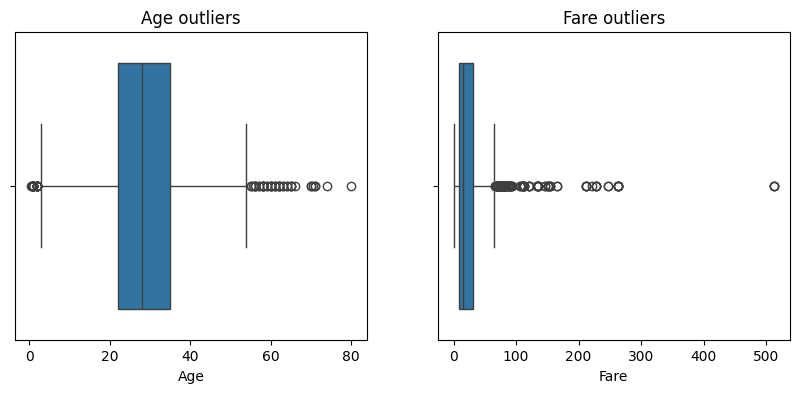

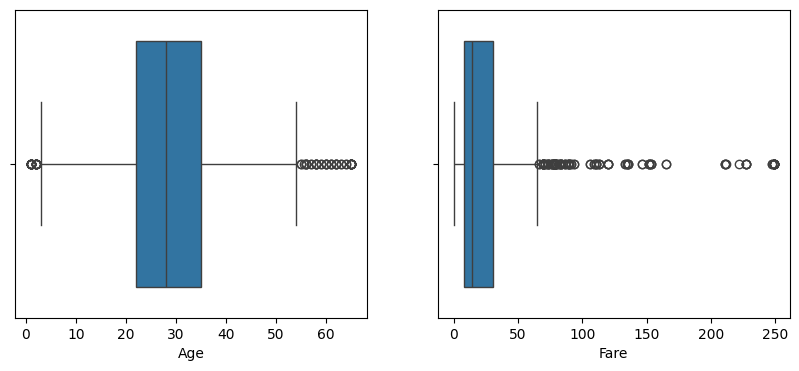

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots to visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(x=df["Age"], ax=axes[0])
sns.boxplot(x=df["Fare"], ax=axes[1])
axes[0].set_title("Age outliers")
axes[1].set_title("Fare outliers")
plt.show()

# Treat outliers using quantile capping
lower_fare, upper_fare = df["Fare"].quantile([0.01, 0.99])
lower_age, upper_age = df["Age"].quantile([0.01, 0.99])

df["Fare"] = df["Fare"].clip(lower=lower_fare, upper=upper_fare)
df["Age"] = df["Age"].clip(lower=lower_age, upper=upper_age)

# Replot to confirm
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(x=df["Age"], ax=axes[0])
sns.boxplot(x=df["Fare"], ax=axes[1])
plt.show()


### Exercise 5: Standardization and Normalization

In [25]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# numeric columns
num_cols = ["Age", "Fare", "FamilySize"]

# Scale features
scaler_std = StandardScaler()
df[["Age", "Fare"]] = scaler_std.fit_transform(df[["Age", "Fare"]])

scaler_minmax = MinMaxScaler()
df[["FamilySize"]] = scaler_minmax.fit_transform(df[["FamilySize"]])

# Show summary
df[num_cols].describe()


,Age,Fare,FamilySize
count,8.910000e+02,8.910000e+02,891.000000
mean,-1.156327e-16,-5.582266e-17,0.090460
std,1.000562e+00,1.000562e+00,0.161346
min,-2.206955e+00,-7.346960e-01,0.000000
25%,-5.695581e-01,-5.485701e-01,0.000000
50%,-1.017302e-01,-3.945992e-01,0.000000
75%,4.440689e-01,-5.288611e-03,0.100000
max,2.783208e+00,5.124239e+00,1.000000


# Exercise 6: Feature Encoding

In [26]:
# One-hot encoding for 'Title' and 'Embarked'
df = pd.get_dummies(df, columns=["Title", "Embarked"], drop_first=True)

# Label encoding for 'Sex'
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,FamilySize,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.569558,1,0,A/5 21171,-0.564109,0.1,False,True,False,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.677983,1,0,PC 17599,0.942548,0.1,False,False,True,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,-0.257673,0,0,STON/O2. 3101282,-0.548227,0.0,True,False,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.444069,1,0,113803,0.514708,0.1,False,False,True,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,0.444069,0,0,373450,-0.545285,0.0,False,True,False,False,False,True


from matplotlib import pyplot as plt
_df_16['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_17['PassengerId'].plot(kind='hist', bins=20, title='PassengerId')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_18['Survived'].plot(kind='hist', bins=20, title='Survived')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_19['Pclass'].plot(kind='hist', bins=20, title='Pclass')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_41['Ticket'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_41, x='index', y='Ticket', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_42['Title_Miss'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_42, x='index', y='Title_Miss', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_43['Title_Mr'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_43, x='index', y='Title_Mr', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

# Exercise 7: Age Group Transformation

In [27]:
# Creating age groups based on standardized Age
# Mean of Age-0, std-1 after scaling, so bins are standardized
bins = [-float("inf"), -1, 0, 1, float("inf")]
labels = ["Child", "Teen", "Adult", "Senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

# One-hot encode the age groups
df = pd.get_dummies(df, columns=["AgeGroup"], drop_first=True)

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,FamilySize,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Embarked_Q,Embarked_S,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.569558,1,0,A/5 21171,-0.564109,0.1,False,True,False,False,False,True,True,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.677983,1,0,PC 17599,0.942548,0.1,False,False,True,False,False,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",1,-0.257673,0,0,STON/O2. 3101282,-0.548227,0.0,True,False,False,False,False,True,True,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.444069,1,0,113803,0.514708,0.1,False,False,True,False,False,True,False,True,False
4,5,0,3,"Allen, Mr. William Henry",0,0.444069,0,0,373450,-0.545285,0.0,False,True,False,False,False,True,False,True,False


In [28]:
print("Final dataset shape:", df.shape)
df.info()
df.describe(include="all").T

Final dataset shape: (891, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      891 non-null    int64  
 1   Survived         891 non-null    int64  
 2   Pclass           891 non-null    int64  
 3   Name             891 non-null    object 
 4   Sex              891 non-null    int64  
 5   Age              891 non-null    float64
 6   SibSp            891 non-null    int64  
 7   Parch            891 non-null    int64  
 8   Ticket           891 non-null    object 
 9   Fare             891 non-null    float64
 10  FamilySize       891 non-null    float64
 11  Title_Miss       891 non-null    bool   
 12  Title_Mr         891 non-null    bool   
 13  Title_Mrs        891 non-null    bool   
 14  Title_Rare       891 non-null    bool   
 15  Embarked_Q       891 non-null    bool   
 16  Embarked_S       891 non-null  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891.0,NaN,NaN,NaN,0.352413,0.47799,0.0,0.0,0.0,1.0,1.0
Age,891.0,NaN,NaN,NaN,-0.0,1.000562,-2.206955,-0.569558,-0.10173,0.444069,2.783208
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,-0.0,1.000562,-0.734696,-0.54857,-0.394599,-0.005289,5.124239
